# Kernel 3: RGB to Grayscale
The goal is to take an RGB-colored image and convert it to grayscale using the luminosity method.
The formula we have to apply to each pixel is:
$$
Z = 0.2126R + 0.7152G + 0.0722B
$$


In [1]:
import torch
from PIL import Image
from torchvision.transforms.functional import to_tensor

img = to_tensor(Image.open("assets/image.jpg").convert("RGB"))
print(img.shape, img.dtype)  # [C, H, W], float in [0, 1]
# Permute to [H, W, 3]
img = img.permute(1, 2, 0)
print(img.shape)

torch.Size([3, 4548, 3840]) torch.float32
torch.Size([4548, 3840, 3])


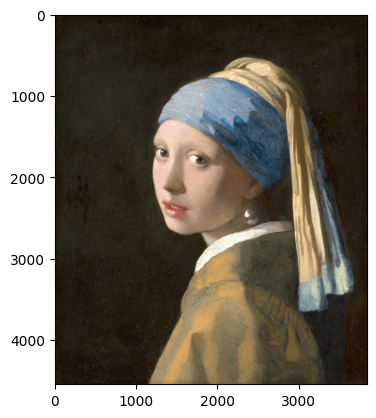

In [2]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.show()

Before doing anything we need to move the image to our GPU and create a buffer to hold the output. The output tensor will have the same size as the input but only 1 channel.

In [3]:
img_gpu = img.to(device="cuda")
h, w, _ = img.shape
img_gray_gpu = torch.empty(h, w, device="cuda", dtype=img_gpu.dtype)
img_gray_gpu.shape

torch.Size([4548, 3840])

### Assignment
Now that the data is on our GPU your goal is to write the kernel that applies the grayscale formula.

Remember that each pixel can be processed independently and our data layout is $[H, W, 3]$.

In [4]:
# Flatten the GPU buffers so that we can access them in the kernel code using a 1D index
img_gpu = img_gpu.contiguous().view(-1)
img_gray_gpu = img_gray_gpu.contiguous().view(-1)

In [5]:
import flydsl.compiler as flyc
import flydsl.expr as fx

def ceildiv(x: int, y: int) -> int:
    return (x + y - 1) // y


@flyc.kernel
def grayscale_kernel(x: fx.Pointer, out: fx.Pointer):
    idx = fx.block_idx.x * fx.block_dim.x + fx.thread_idx.x
    
    # There are 3 channels per pixel
    r = x[idx * 3] 
    g = x[idx * 3 + 1]
    b = x[idx * 3 + 2]

    # out only has 1 channel per pixel
    out[idx] = r * 0.2126 + g * 0.7152 + b * 0.0722


@flyc.jit
def grayscale(x: fx.Pointer, out: fx.Pointer, w: fx.Int32, h: fx.Int32, stream: fx.Stream):
    block_dim = 256
    ne = w * h
    grid_x = ceildiv(ne, block_dim)
    grayscale_kernel(x, out).launch(grid=(grid_x, 1, 1), block=(block_dim, 1, 1), stream=stream)

Once your code is ready use this code to check if it actually works

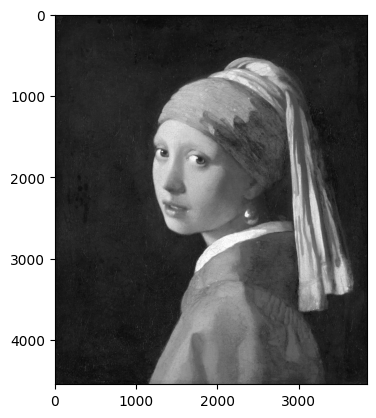

In [6]:
img_gray_gpu.zero_()

grayscale(img_gpu, img_gray_gpu, w, h, torch.cuda.default_stream())
torch.cuda.synchronize()

plt.imshow(img_gray_gpu.reshape(h, w).to("cpu"), cmap="gray")
plt.show()

### Solution

In [ ]:

@flyc.kernel
def grayscale_kernel(x: fx.Pointer, out: fx.Pointer):
    idx = fx.block_idx.x * fx.block_dim.x + fx.thread_idx.x
    
    # There are 3 channels per pixel
    r = x[idx * 3] 
    g = x[idx * 3 + 1]
    b = x[idx * 3 + 2]

    # out only has 1 channel per pixel
    out[idx] = r * 0.2126 + g * 0.7152 + b * 0.0722


@flyc.jit
def grayscale(x: fx.Pointer, out: fx.Pointer, w: fx.Int32, h: fx.Int32, stream: fx.Stream):
    block_dim = 256
    ne = w * h
    grid_x = ceildiv(ne, block_dim)
    grayscale_kernel(x, out).launch(grid=(grid_x, 1, 1), block=(block_dim, 1, 1), stream=stream)


### Quiz

What do you think the generated code looks like? Will there be any vectorization?

The answer is **yes**. Since our input data layout is $[H, W, 3]$, each thread loads 3 consecutive elements. The compiler sees that and, instead of producing 3 scalar loads, it produces 1 **vectorized load**. This can be seen easily by dumping the generated IR for this kernel using `FLYDSL_DUMP_IR=1`.

Generated code:
```asm
global_load_dwordx3 v[0:2], v[0:1], off     ;load 3 32-bits elements from addr in v0, v1 and put them in v0, v1, v2  
s_mov_b32 s0, 0x3e59b3d0                    ;load the FP32 value `0.2126` in scalar register s0
s_mov_b32 s1, 0x3d93dd98                    ;load the FP32 value `0.0722` in scalar register s1
s_waitcnt vmcnt(0)                          ;wait until all VMEM ops are done
v_mul_f32_e32 v3, 0x3f371759, v1            ;multiply v1 with `0.7152` and put it in v3
v_mov_b32_e32 v1, v2                        ;move the value in v2 to v1
v_pk_mul_f32 v[0:1], v[0:1], s[0:1]         ;multiple v0 with s0 and v1 with s1 in place
v_add_f32_e32 v0, v0, v3                    ;add v0 and v3 in place
v_add_f32_e32 v2, v0, v1                    ;add v0 and v1 and put the result in v2
v_lshl_add_u64 v[0:1], v[4:5], 2, s[6:7]    ;destination address computation
global_store_dword v[0:1], v2, off          ;store the single 32-bits value in v2 at the memory address stored in v0, v1
```

As you can see, there's only 1 load instruction (`global_load_dwordx3` loads 3 pixels, 32-bits each).


*P.S.*: to check the HEX numbers you can use an online tool like https://gregstoll.com/~gregstoll/floattohex/